# 🚨 Análisis de Seguridad en Costa Rica
## Accidentes de tránsito, homicidios y femicidios

**Autor:** Ericka Valverde Navarro  
**Proyecto de portafolio:** Análisis de datos con enfoque social en Costa Rica  

### Objetivo
Analizar el comportamiento de eventos de seguridad en Costa Rica para identificar patrones por tipo de evento, ubicación, hora y tendencia temporal.

### Preguntas clave
- ¿Qué provincias presentan mayor incidencia?
- ¿Qué tipo de evento ocurre con mayor frecuencia?
- ¿Cómo evolucionan los eventos a lo largo del tiempo?
- ¿Existen patrones horarios o condiciones asociadas?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

# Configuración visual
plt.style.use("default")
sns.set_theme(style="whitegrid", context="talk")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)
pd.set_option("display.float_format", "{:,.2f}".format)

In [6]:
df = pd.read_csv("../data/seguridad_cr.csv")
df.head()

,id_evento,fecha,anio,mes,dia_semana,hora,provincia,canton,tipo_evento,cantidad_eventos,condicion,severidad,victimas_fatales,heridos,latitud,longitud
0,1,2022-05-10,2022,5,Tuesday,09:30,Guanacaste,Hojancha,Accidente de tránsito,1,Noche,Grave,0,1,10.63,-85.42
1,2,2023-07-18,2023,7,Tuesday,08:10,Cartago,Paraíso,Accidente de tránsito,1,Seco,Leve,0,4,9.80,-83.82
2,3,2023-02-04,2023,2,Saturday,20:45,Heredia,Heredia,Accidente de tránsito,1,Húmedo,Leve,0,4,9.95,-84.10
3,4,2022-12-31,2022,12,Saturday,18:10,Guanacaste,Carrillo,Accidente de tránsito,1,Húmedo,Moderado,0,0,10.53,-85.56
4,5,2024-06-26,2024,6,Wednesday,18:40,Heredia,Santa Bárbara,Homicidio,1,Húmedo,Fatal,1,0,10.01,-84.12


In [7]:
print("Dimensiones del dataset:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores nulos:")
print(df.isnull().sum())

Dimensiones del dataset: (150000, 16)

Columnas:
['id_evento', 'fecha', 'anio', 'mes', 'dia_semana', 'hora', 'provincia', 'canton', 'tipo_evento', 'cantidad_eventos', 'condicion', 'severidad', 'victimas_fatales', 'heridos', 'latitud', 'longitud']

Tipos de datos:
id_evento             int64
fecha                object
anio                  int64
mes                   int64
dia_semana           object
hora                 object
provincia            object
canton               object
tipo_evento          object
cantidad_eventos      int64
condicion            object
severidad            object
victimas_fatales      int64
heridos               int64
latitud             float64
longitud            float64
dtype: object

Valores nulos:
id_evento           0
fecha               0
anio                0
mes                 0
dia_semana          0
hora                0
provincia           0
canton              0
tipo_evento         0
cantidad_eventos    0
condicion           0
severidad       

In [8]:
# Convertir fecha a datetime
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

# Crear columnas útiles para análisis temporal
df["anio"] = df["fecha"].dt.year
df["mes"] = df["fecha"].dt.month
df["nombre_mes"] = df["fecha"].dt.month_name()
df["dia_semana"] = df["fecha"].dt.day_name()

# Estandarizar texto si aplica
for col in ["provincia", "canton", "tipo_evento", "condicion", "severidad"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

df.head()

,id_evento,fecha,anio,mes,dia_semana,hora,provincia,canton,tipo_evento,cantidad_eventos,condicion,severidad,victimas_fatales,heridos,latitud,longitud,nombre_mes
0,1,2022-05-10,2022,5,Tuesday,09:30,Guanacaste,Hojancha,Accidente de tránsito,1,Noche,Grave,0,1,10.63,-85.42,May
1,2,2023-07-18,2023,7,Tuesday,08:10,Cartago,Paraíso,Accidente de tránsito,1,Seco,Leve,0,4,9.80,-83.82,July
2,3,2023-02-04,2023,2,Saturday,20:45,Heredia,Heredia,Accidente de tránsito,1,Húmedo,Leve,0,4,9.95,-84.10,February
3,4,2022-12-31,2022,12,Saturday,18:10,Guanacaste,Carrillo,Accidente de tránsito,1,Húmedo,Moderado,0,0,10.53,-85.56,December
4,5,2024-06-26,2024,6,Wednesday,18:40,Heredia,Santa Bárbara,Homicidio,1,Húmedo,Fatal,1,0,10.01,-84.12,June


In [9]:
display(Markdown("## Resumen inicial del dataset"))

print(f"Total de registros: {df.shape[0]:,}")
print(f"Cantidad de columnas: {df.shape[1]}")
print(f"Rango de fechas: {df['fecha'].min().date()} a {df['fecha'].max().date()}")
print(f"Tipos de evento disponibles: {df['tipo_evento'].nunique()}")
print(f"Provincias incluidas: {df['provincia'].nunique()}")

## Resumen inicial del dataset

Total de registros: 150,000
Cantidad de columnas: 17
Rango de fechas: 2020-01-01 a 2025-12-31
Tipos de evento disponibles: 3
Provincias incluidas: 7


In [10]:
total_eventos = len(df)
total_accidentes = (df["tipo_evento"] == "accidente").sum()
total_homicidios = (df["tipo_evento"] == "homicidio").sum()
total_femicidios = (df["tipo_evento"] == "femicidio").sum()

victimas_fatales = df["victimas_fatales"].sum() if "victimas_fatales" in df.columns else 0
heridos = df["heridos"].sum() if "heridos" in df.columns else 0

display(Markdown("## Indicadores generales"))
print(f"Total de eventos registrados: {total_eventos:,}")
print(f"Accidentes: {total_accidentes:,}")
print(f"Homicidios: {total_homicidios:,}")
print(f"Femicidios: {total_femicidios:,}")
print(f"Víctimas fatales: {victimas_fatales:,}")
print(f"Heridos: {heridos:,}")

## Indicadores generales

Total de eventos registrados: 150,000
Accidentes: 0
Homicidios: 0
Femicidios: 0
Víctimas fatales: 36,583
Heridos: 161,496


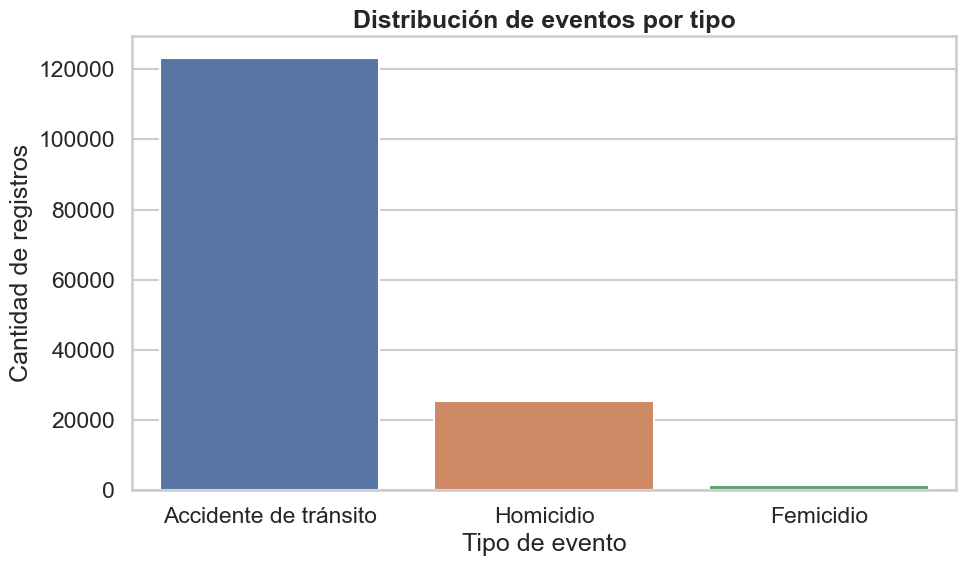

In [11]:
eventos_tipo = df["tipo_evento"].value_counts().reset_index()
eventos_tipo.columns = ["tipo_evento", "cantidad"]

plt.figure(figsize=(10,6))
sns.barplot(data=eventos_tipo, x="tipo_evento", y="cantidad", hue="tipo_evento", legend=False)
plt.title("Distribución de eventos por tipo", fontsize=18, weight="bold")
plt.xlabel("Tipo de evento")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

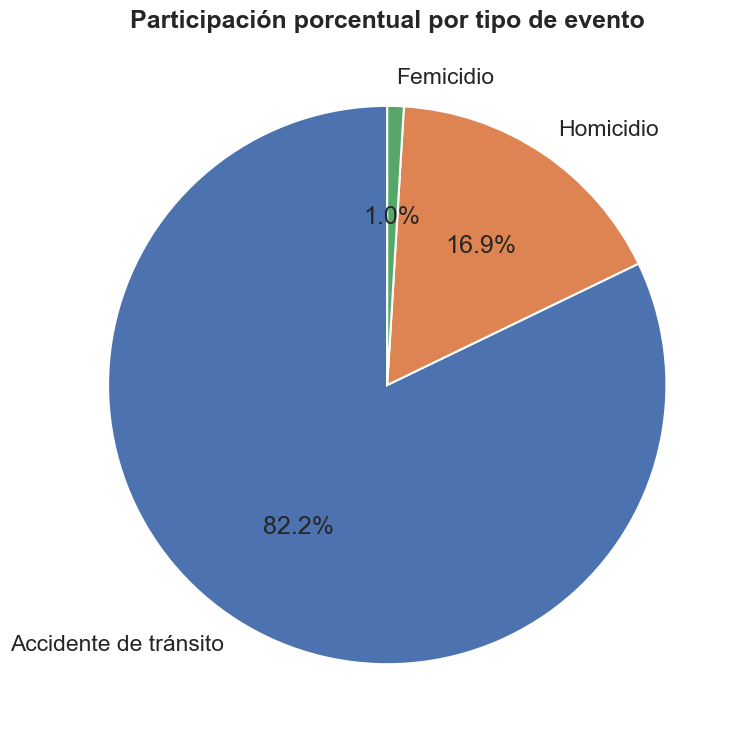

In [12]:
plt.figure(figsize=(8,8))
plt.pie(
    eventos_tipo["cantidad"],
    labels=eventos_tipo["tipo_evento"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Participación porcentual por tipo de evento", fontsize=18, weight="bold")
plt.tight_layout()
plt.show()

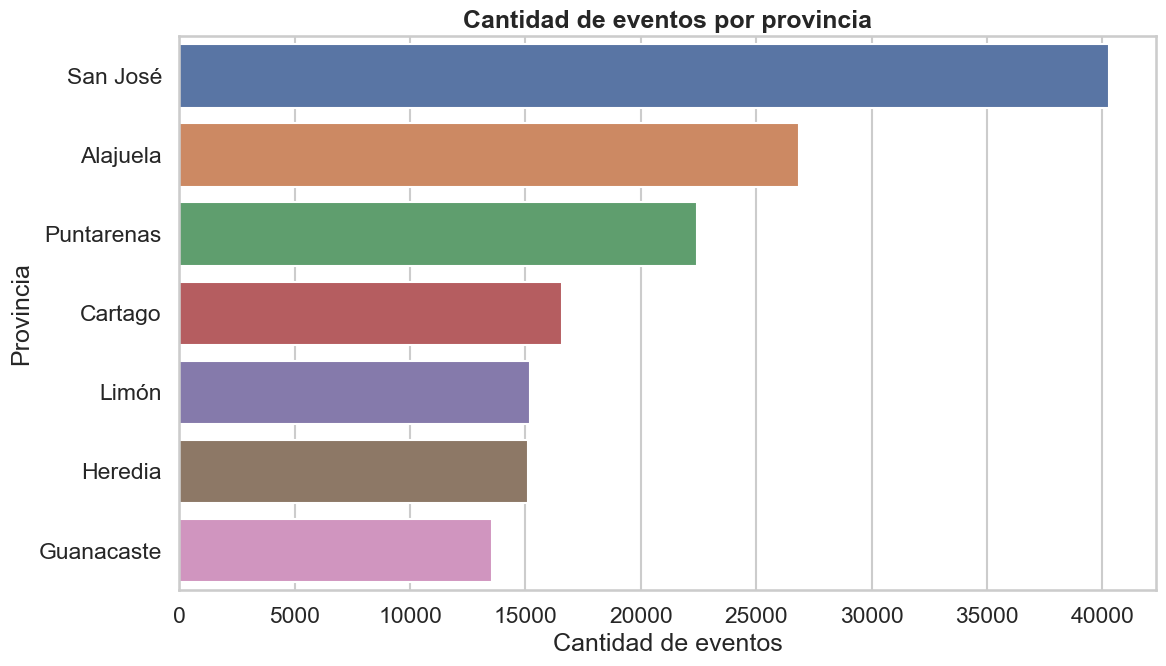

In [13]:
prov_eventos = df["provincia"].value_counts().sort_values(ascending=False).reset_index()
prov_eventos.columns = ["provincia", "cantidad"]

plt.figure(figsize=(12,7))
sns.barplot(data=prov_eventos, x="cantidad", y="provincia", hue="provincia", legend=False)
plt.title("Cantidad de eventos por provincia", fontsize=18, weight="bold")
plt.xlabel("Cantidad de eventos")
plt.ylabel("Provincia")
plt.tight_layout()
plt.show()

In [14]:
display(Markdown("## Provincias con mayor cantidad de eventos"))
prov_eventos.head(10)

## Provincias con mayor cantidad de eventos

,provincia,cantidad
0,San José,40304
1,Alajuela,26834
2,Puntarenas,22445
3,Cartago,16567
4,Limón,15181
5,Heredia,15100
6,Guanacaste,13569


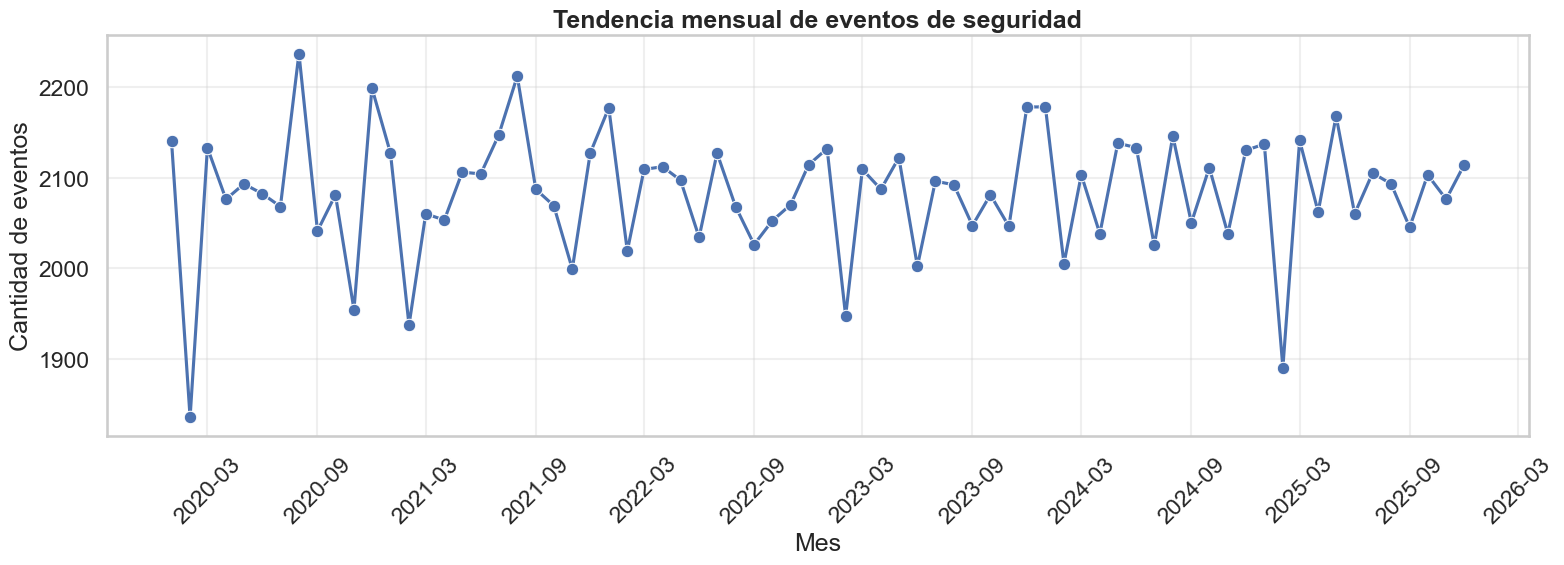

In [25]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns

# Agrupar por mes
eventos_mes = (
    df.groupby(df["fecha"].dt.to_period("M"))
      .size()
      .reset_index(name="cantidad")
)

# Convertir a fecha real
eventos_mes["fecha"] = eventos_mes["fecha"].dt.to_timestamp()

# Ordenar por fecha por seguridad
eventos_mes = eventos_mes.sort_values("fecha")

plt.figure(figsize=(16, 6))

ax = sns.lineplot(
    data=eventos_mes,
    x="fecha",
    y="cantidad",
    marker="o"
)

ax.set_title("Tendencia mensual de eventos de seguridad", fontsize=18, weight="bold")
ax.set_xlabel("Mes")
ax.set_ylabel("Cantidad de eventos")

# Mostrar menos marcas en el eje X
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

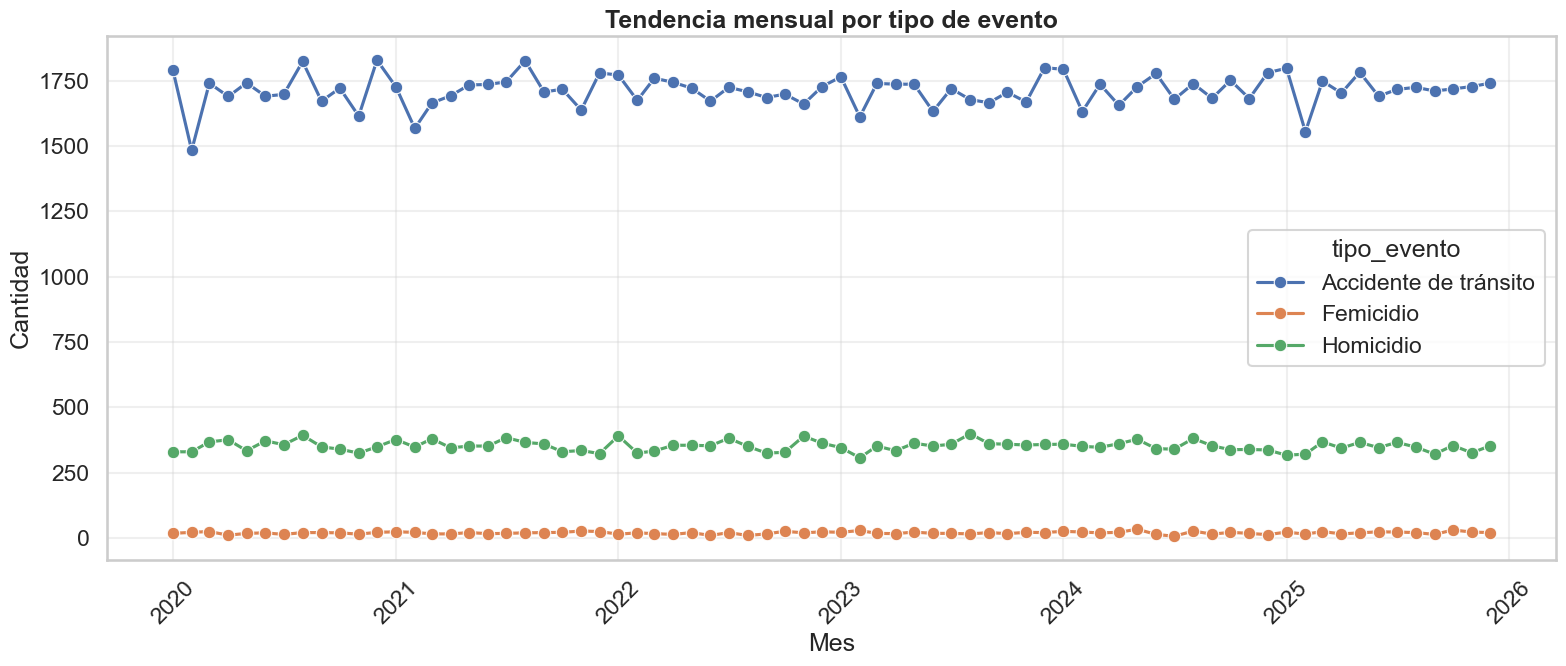

In [24]:
eventos_tipo_mes = (
    df.groupby([df["fecha"].dt.to_period("M"), "tipo_evento"])
      .size()
      .reset_index(name="cantidad")
)

# Convertir el periodo mensual a timestamp real
eventos_tipo_mes["fecha"] = eventos_tipo_mes["fecha"].dt.to_timestamp()

plt.figure(figsize=(16,7))

sns.lineplot(
    data=eventos_tipo_mes,
    x="fecha",
    y="cantidad",
    hue="tipo_evento",
    marker="o"
)

plt.title("Tendencia mensual por tipo de evento", fontsize=18, weight="bold")
plt.xlabel("Mes")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
df["hora"] = pd.to_datetime(df["hora"], errors="coerce")
df["hora_num"] = df["hora"].dt.hour
eventos_hora = df.groupby("hora_num").size().reset_index(name="cantidad")

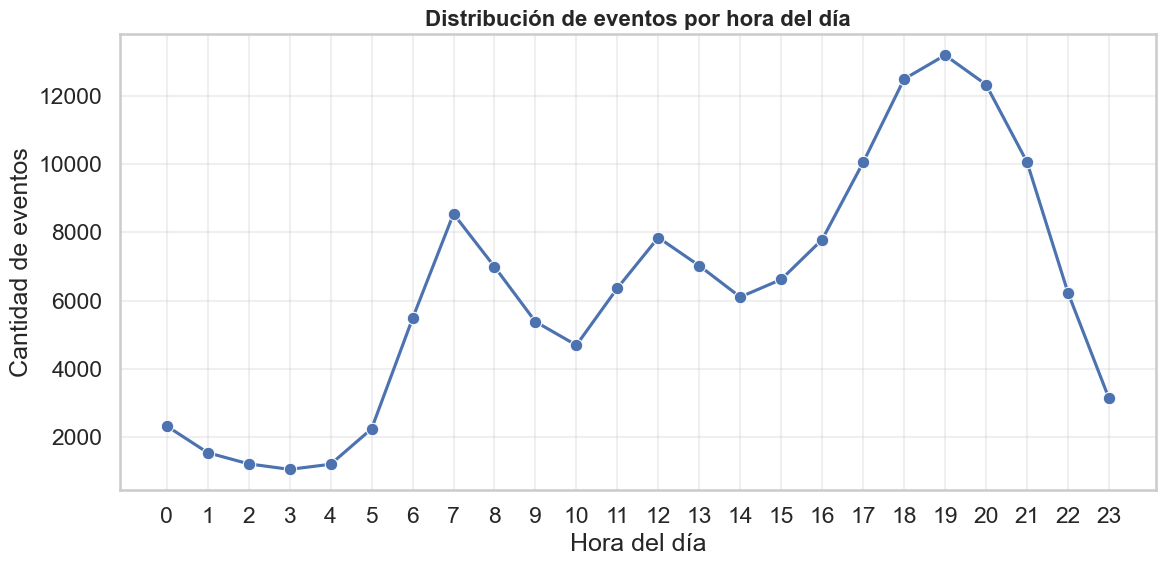

In [23]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=eventos_hora,
    x="hora_num",
    y="cantidad",
    marker="o"
)

plt.title("Distribución de eventos por hora del día", fontsize=16, weight="bold")
plt.xlabel("Hora del día")
plt.ylabel("Cantidad de eventos")

plt.xticks(range(0,24))  # solo 0 a 23
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

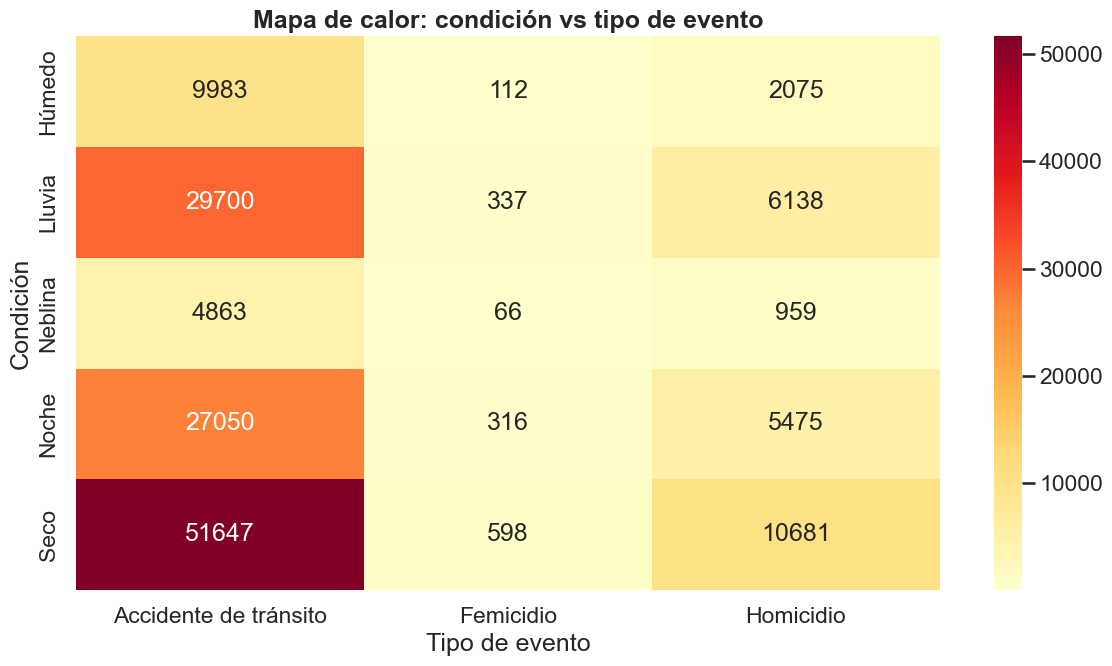

In [18]:
if "condicion" in df.columns:
    tabla_condicion = pd.crosstab(df["condicion"], df["tipo_evento"])

    plt.figure(figsize=(12,7))
    sns.heatmap(tabla_condicion, annot=True, fmt="d", cmap="YlOrRd")
    plt.title("Mapa de calor: condición vs tipo de evento", fontsize=18, weight="bold")
    plt.xlabel("Tipo de evento")
    plt.ylabel("Condición")
    plt.tight_layout()
    plt.show()

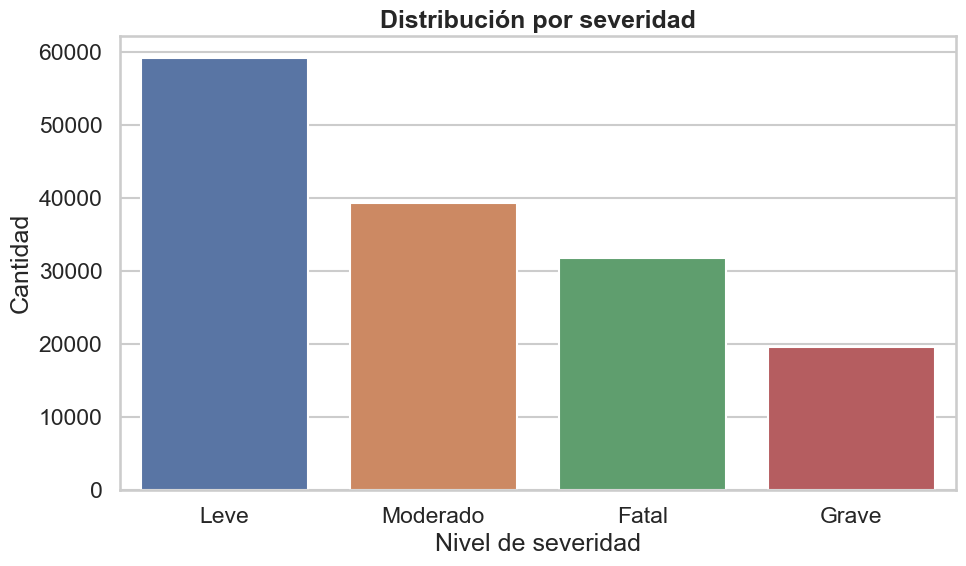

In [19]:
if "severidad" in df.columns:
    sev = df["severidad"].value_counts().reset_index()
    sev.columns = ["severidad", "cantidad"]

    plt.figure(figsize=(10,6))
    sns.barplot(data=sev, x="severidad", y="cantidad", hue="severidad", legend=False)
    plt.title("Distribución por severidad", fontsize=18, weight="bold")
    plt.xlabel("Nivel de severidad")
    plt.ylabel("Cantidad")
    plt.tight_layout()
    plt.show()

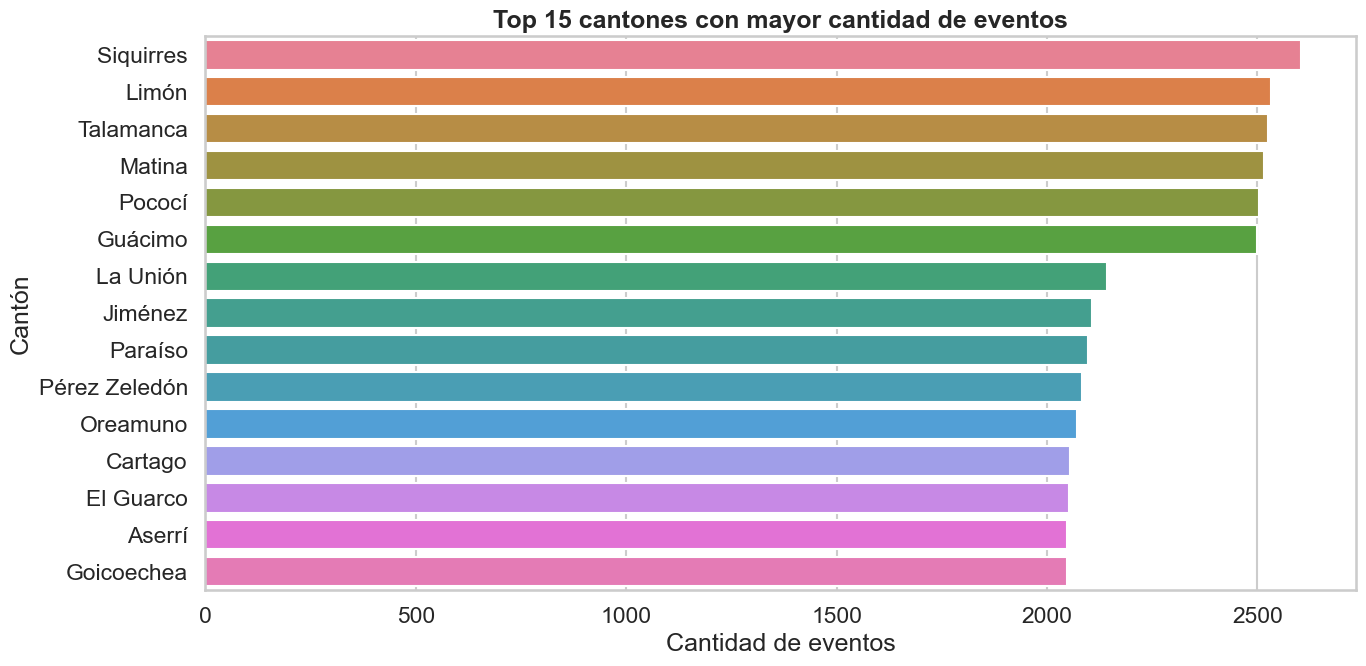

In [20]:
top_cantones = df["canton"].value_counts().head(15).reset_index()
top_cantones.columns = ["canton", "cantidad"]

plt.figure(figsize=(14,7))
sns.barplot(data=top_cantones, x="cantidad", y="canton", hue="canton", legend=False)
plt.title("Top 15 cantones con mayor cantidad de eventos", fontsize=18, weight="bold")
plt.xlabel("Cantidad de eventos")
plt.ylabel("Cantón")
plt.tight_layout()
plt.show()

## Hallazgos clave

A partir del análisis exploratorio se identifican los siguientes patrones:

- Los accidentes de tránsito representan la mayor proporción de eventos registrados.
- Existen provincias y cantones con una concentración más alta de incidentes.
- La frecuencia de eventos muestra variaciones temporales importantes.
- Se observan franjas horarias con mayor incidencia, lo que puede asociarse a movilidad, exposición o actividad urbana.
- Algunas condiciones presentan mayor relación con determinados tipos de evento.


## Recomendaciones

Con base en los resultados obtenidos, se sugieren las siguientes acciones:

1. Priorizar campañas de prevención en provincias y cantones con mayor incidencia.
2. Reforzar medidas de seguridad vial en horarios críticos.
3. Diseñar estrategias diferenciadas según tipo de evento.
4. Integrar nuevas variables como población, densidad vehicular o clima para enriquecer futuros análisis.
5. Desarrollar dashboards interactivos para facilitar el monitoreo continuo.


## Conclusión

Este proyecto demuestra cómo el análisis de datos puede contribuir a comprender fenómenos de seguridad en Costa Rica desde una perspectiva territorial y temporal.  

Además de identificar patrones relevantes, este tipo de análisis puede servir como base para la toma de decisiones en prevención, planificación y monitoreo.

